# Beyond text: images and PDFs as LLM input

**The Agent Build Log · Build #007 · GenAI & LLM Foundations 7/8**

Builds #003-#006 sent text. Real inputs are often screenshots, scanned invoices and PDFs with charts in them.
This build sends both to **Claude Haiku 5.5** and measures what they cost and what the model actually reads.

1. [An invoice, five image sizes](#1-an-invoice-five-image-sizes)
2. [A PDF whose numbers live in pictures](#2-a-pdf-whose-numbers-live-in-pictures)
3. [Findings](#3-findings)

**Model note:** from this build the series uses Claude Haiku 5.5 ($0.10 / $0.50 per million input / output tokens
for prompts up to 100K tokens). Haiku 5.5 thinks by default; extraction doesn't need it, so these calls turn it off.
Build #008 compares it with Haiku 4.5 and the bigger models.

**Needs:** an Anthropic API key in a `.env` file. A full run costs under **2 cents**.

In [1]:
import base64, io, json, os, random, re, time
from pathlib import Path

import pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from PIL import Image, ImageDraw, ImageFont
from pydantic import BaseModel
from pypdf import PdfReader
from dotenv import load_dotenv
import anthropic

load_dotenv(Path.cwd() / ".env") or load_dotenv(Path.cwd().parents[1] / ".env")
assert os.environ.get("ANTHROPIC_API_KEY"), "Set ANTHROPIC_API_KEY in a .env file (see README)"
pd.set_option("display.width", 160)
plt.rcParams["pdf.fonttype"] = 42   # real text in the PDF, so text extraction can find it

MODEL = "claude-haiku-5-5"
PRICE = {"input": 0.10, "output": 0.50}   # $ per 1M tokens (prompts up to 100K tokens)
NO_THINKING = {"type": "disabled"}       # Haiku 5.5 thinks by default; extraction doesn't need it
client = anthropic.Anthropic()
DATA = Path("data"); DATA.mkdir(exist_ok=True)

def cost(u) -> float:
    return (u.input_tokens * PRICE["input"] + u.output_tokens * PRICE["output"]) / 1e6

def b64(data: bytes) -> str:
    return base64.standard_b64encode(data).decode()

print("model:", MODEL, "| sdk:", anthropic.__version__)

model: claude-haiku-5-5 | sdk: 1.13.0


## 1. An invoice, five image sizes

A synthetic invoice (fixed seed, so every reader gets the same one) with 20 line items, rendered at 2400×3000 px,
then downscaled. For each size: how many tokens the image costs, and how many of its 62 values
(20 × qty, unit price, amount, plus the total and the invoice number) come back correct.

20 lines, total 4995.41


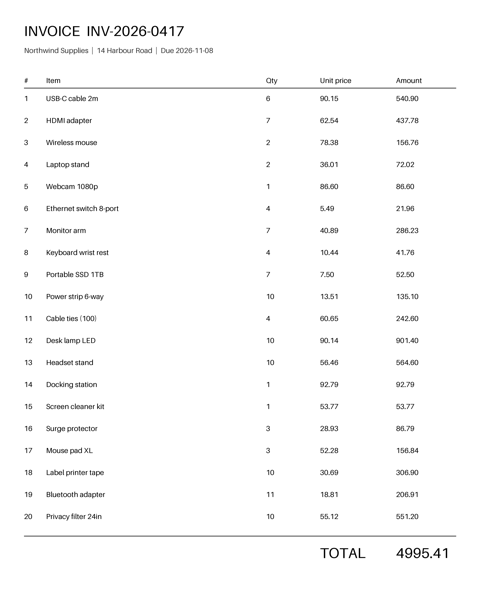

In [2]:
rng = random.Random(7)
ITEMS = ["USB-C cable 2m", "HDMI adapter", "Wireless mouse", "Laptop stand", "Webcam 1080p", "Ethernet switch 8-port",
         "Monitor arm", "Keyboard wrist rest", "Portable SSD 1TB", "Power strip 6-way", "Cable ties (100)", "Desk lamp LED",
         "Headset stand", "Docking station", "Screen cleaner kit", "Surge protector", "Mouse pad XL", "Label printer tape",
         "Bluetooth adapter", "Privacy filter 24in"]
LINES = []
for name in ITEMS:
    qty, unit = rng.randint(1, 12), round(rng.uniform(2, 95), 2)
    LINES.append({"item": name, "qty": qty, "unit_price": unit, "amount": round(qty * unit, 2)})
TOTAL = round(sum(l["amount"] for l in LINES), 2)
INVOICE_NO = "INV-2026-0417"

def render_invoice() -> Image.Image:
    img = Image.new("RGB", (2400, 3000), "white"); d = ImageDraw.Draw(img)
    big, f = ImageFont.load_default(size=72), ImageFont.load_default(size=36)
    d.text((120, 110), f"INVOICE  {INVOICE_NO}", font=big, fill="black")
    d.text((120, 230), "Northwind Supplies  |  14 Harbour Road  |  Due 2026-11-08", font=f, fill="#333")
    cols = [(120, "#"), (230, "Item"), (1330, "Qty"), (1600, "Unit price"), (1980, "Amount")]
    for x, h in cols: d.text((x, 380), h, font=f, fill="black")
    d.line((120, 440, 2280, 440), fill="black", width=3)
    y = 470
    for i, l in enumerate(LINES, 1):
        for x, v in zip([c[0] for c in cols], [i, l["item"], l["qty"], f"{l['unit_price']:.2f}", f"{l['amount']:.2f}"]):
            d.text((x, y), str(v), font=f, fill="black")
        y += 110
    d.line((120, y + 10, 2280, y + 10), fill="black", width=3)
    d.text((1600, y + 50), "TOTAL", font=big, fill="black"); d.text((1980, y + 50), f"{TOTAL:.2f}", font=big, fill="black")
    return img

invoice = render_invoice()
invoice.save(DATA / "invoice.png")
print(f"{len(LINES)} lines, total {TOTAL}")
invoice.resize((480, 600))

In [3]:
class Line(BaseModel):
    item: str
    qty: int
    unit_price: float
    amount: float

class Invoice(BaseModel):
    invoice_number: str
    lines: list[Line]
    total: float

def png_bytes(img: Image.Image) -> bytes:
    buf = io.BytesIO(); img.save(buf, format="PNG"); return buf.getvalue()

def image_block(img: Image.Image) -> dict:
    return {"type": "image", "source": {"type": "base64", "media_type": "image/png", "data": b64(png_bytes(img))}}

norm = lambda s: re.sub(r"[^a-z0-9]", "", s.lower())

def score(inv: Invoice) -> int:
    got = {norm(l.item): l for l in inv.lines}
    ok = int(inv.invoice_number.strip() == INVOICE_NO) + int(abs(inv.total - TOTAL) < 0.005)
    for l in LINES:
        g = got.get(norm(l["item"]))
        if g:
            ok += (g.qty == l["qty"]) + (abs(g.unit_price - l["unit_price"]) < 0.005) + (abs(g.amount - l["amount"]) < 0.005)
    return ok

PROMPT = "Extract this invoice: the invoice number, every line item, and the total. Copy numbers exactly as printed."
rows = []
for long_edge in [3000, 1500, 1000, 750, 500, 375, 300, 250]:
    img = invoice.resize((round(2400 * long_edge / 3000), long_edge), Image.LANCZOS)
    msgs = [{"role": "user", "content": [image_block(img), {"type": "text", "text": PROMPT}]}]
    image_tokens = client.messages.count_tokens(model=MODEL, messages=msgs).input_tokens
    for run in range(3):
        t0 = time.perf_counter()
        r = client.messages.parse(model=MODEL, max_tokens=4000, thinking=NO_THINKING, messages=msgs, output_format=Invoice)
        rows.append({"size": f"{img.width}x{img.height}", "long edge": long_edge, "run": run + 1,
                     "input tokens": r.usage.input_tokens, "counted": image_tokens, "correct (of 62)": score(r.parsed_output),
                     "seconds": round(time.perf_counter() - t0, 2), "cost $": cost(r.usage)})
img_runs = pd.DataFrame(rows)
img_summary = img_runs.groupby(["long edge", "size"], sort=False).agg(
    input_tokens=("input tokens", "first"), correct_min=("correct (of 62)", "min"), correct_max=("correct (of 62)", "max"),
    cost_per_call=("cost $", "mean")).reset_index()
img_summary["cost_per_call"] = img_summary["cost_per_call"].round(6)
img_summary

,long edge,size,input_tokens,correct_min,correct_max,cost_per_call
0,3000,2400x3000,5337,62,62,0.000916
1,1500,1200x1500,2885,62,62,0.000671
2,1000,800x1000,1607,62,62,0.000560
3,750,600x750,1157,62,62,0.000498
4,500,400x500,833,62,62,0.000466
5,375,300x375,717,56,57,0.000454
6,300,240x300,662,21,22,0.000500
7,250,200x250,635,2,5,0.000466


**Reading the table:** tokens fall with pixel count. Accuracy holds, then drops. The cheapest size that still gets
every value right is the one to ship. Below it, look at *how* it fails: does the model refuse, or return
well-formed JSON with wrong numbers? (Structured outputs guarantee the shape, not the values, as in build #004.)

In [4]:
first_bad = img_summary[img_summary["correct_min"] < 62]
SMALL = int(first_bad["long edge"].iloc[0]) if len(first_bad) else 250
small = invoice.resize((round(2400 * SMALL / 3000), SMALL), Image.LANCZOS)
r = client.messages.parse(model=MODEL, max_tokens=4000, thinking=NO_THINKING, output_format=Invoice,
                          messages=[{"role": "user", "content": [image_block(small), {"type": "text", "text": PROMPT}]}])
inv = r.parsed_output
got = {norm(l.item): l for l in inv.lines}
label = f"read at {small.width}x{small.height}"
compare_small = pd.DataFrame([{"item": l["item"], "true unit price": l["unit_price"],
                               label: getattr(got.get(norm(l["item"])), "unit_price", None)} for l in LINES[:8]])
print(f"{small.width}x{small.height}: {score(inv)}/62 correct | total read as {inv.total} (true {TOTAL}) | {len(inv.lines)} lines returned"
      f" | stop_reason {r.stop_reason}")
compare_small

300x375: 59/62 correct | total read as 4995.41 (true 4995.41) | 20 lines returned | stop_reason end_turn


,item,true unit price,read at 300x375
0,USB-C cable 2m,90.15,90.10
1,HDMI adapter,62.54,62.64
2,Wireless mouse,78.38,78.38
3,Laptop stand,36.01,36.01
4,Webcam 1080p,86.60,86.60
5,Ethernet switch 8-port,5.49,5.49
6,Monitor arm,40.89,40.89
7,Keyboard wrist rest,10.44,10.44


## 2. A PDF whose numbers live in pictures

A 3-page quarterly report. Page 1 is text. Page 2 has a bar chart and page 3 a scanned table, both embedded as
**images**, which is how charts and scans usually end up in real PDFs. 8 questions: 4 answered by the text,
4 only by the pictures.

Two ways to send it: extract the text with `pypdf` and send that, or send the PDF itself as a `document` block,
where the model sees each page as text **and** as an image.

In [5]:
def chart_png() -> Image.Image:
    fig, ax = plt.subplots(figsize=(6, 3.2), dpi=150)
    bars = ax.bar(["Jul", "Aug", "Sep"], [1240, 1515, 1388], color="#5B6CFF")
    ax.bar_label(bars, labels=["1,240", "1,515", "1,388"], fontsize=12); ax.set_ylim(0, 1800)
    ax.set_title("Monthly signups, Q3 2026"); fig.tight_layout()
    buf = io.BytesIO(); fig.savefig(buf, format="png"); plt.close(fig); return Image.open(buf).convert("RGB")

def table_png() -> Image.Image:
    img = Image.new("RGB", (1200, 520), "#F4F1EA"); d = ImageDraw.Draw(img); f = ImageFont.load_default(size=34)
    d.text((40, 30), "Regional revenue, Q3 2026 ($M)", font=f, fill="black")
    for i, (region, v) in enumerate([("North", "1.62"), ("South", "1.21"), ("West", "1.99")]):
        d.text((60, 140 + i * 110), region, font=f, fill="black"); d.text((700, 140 + i * 110), v, font=f, fill="black")
    return img.rotate(1.2, expand=True, fillcolor="white")   # a slightly crooked scan

def page(pdf, title, body=None, picture=None):
    fig = plt.figure(figsize=(8.27, 11.69)); fig.text(0.08, 0.93, title, fontsize=18, weight="bold")
    if body: fig.text(0.08, 0.88, body, fontsize=11, va="top", wrap=True)
    if picture is not None:
        ax = fig.add_axes([0.08, 0.40, 0.84, 0.45]); ax.imshow(picture); ax.axis("off")
    pdf.savefig(fig); plt.close(fig)

with PdfPages(DATA / "q3-report.pdf") as pdf:
    page(pdf, "Q3 2026 operations report",
         "Q3 revenue was $4.82M, up 12% on Q2.\nHeadcount ended the quarter at 137.\n"
         "Customer churn was 2.9% for the quarter.\nSignups and regional revenue are on the next pages.")
    page(pdf, "Signups", "Chart exported from the analytics dashboard.", chart_png())
    page(pdf, "Regional revenue", "Scanned from the finance pack.", table_png())

pdf_bytes = (DATA / "q3-report.pdf").read_bytes()
extracted = "\n\n".join(p.extract_text() for p in PdfReader(DATA / "q3-report.pdf").pages)
print(f"PDF: {len(pdf_bytes) / 1024:.0f} KB, 3 pages\n--- what pypdf extracts ---\n{extracted}")

PDF: 68 KB, 3 pages
--- what pypdf extracts ---
Q3 2026 operations report
Q3 revenue was $4.82M, up 12% on Q2.
Headcount ended the quarter at 137.
Customer churn was 2.9% for the quarter.
Signups and regional revenue are on the next pages.

Signups
Chart exported from the analytics dashboard.

Regional revenue
Scanned from the finance pack.


In [6]:
QUESTIONS = {
    "revenue": ("Q3 revenue, in $M", 4.82), "growth": ("Revenue growth on Q2, in %", 12),
    "headcount": ("Headcount at the end of the quarter", 137), "churn": ("Customer churn, in %", 2.9),
    "aug": ("August signups", 1515), "sep": ("September signups", 1388),
    "west": ("West region revenue, in $M", 1.99), "south": ("South region revenue, in $M", 1.21),
}
IN_PICTURES = {"aug", "sep", "west", "south"}

class Answer(BaseModel):
    id: str
    value: float | None

class Answers(BaseModel):
    answers: list[Answer]

ASK = ("Answer each question using only the document. Give a plain number in the unit asked. "
       "If the document doesn't contain the answer, use null.\n"
       + "\n".join(f"{k}: {q}" for k, (q, _) in QUESTIONS.items()))

def ask_pdf(mode: str):
    if mode == "extracted text":
        content = [{"type": "text", "text": f"<document>\n{extracted}\n</document>"}, {"type": "text", "text": ASK}]
    else:
        content = [{"type": "document", "source": {"type": "base64", "media_type": "application/pdf", "data": b64(pdf_bytes)}},
                   {"type": "text", "text": ASK}]
    msgs = [{"role": "user", "content": content}]
    t0 = time.perf_counter()
    r = client.messages.parse(model=MODEL, max_tokens=1000, thinking=NO_THINKING, messages=msgs, output_format=Answers)
    got = {a.id: a.value for a in r.parsed_output.answers}
    out = {"mode": mode, "input tokens": r.usage.input_tokens, "seconds": round(time.perf_counter() - t0, 2), "cost $": cost(r.usage)}
    for k, (_, truth) in QUESTIONS.items():
        v = got.get(k)
        out[k] = "correct" if v is not None and abs(v - truth) < 1e-6 else ("null" if v is None else f"wrong ({v:g})")
    return out

pdf_runs = pd.DataFrame([ask_pdf(m) for m in ["extracted text", "native PDF"] for _ in range(3)])
pdf_runs

,mode,input tokens,seconds,cost $,revenue,growth,headcount,churn,aug,sep,west,south
0,extracted text,678,1.56,0.000122,correct,correct,correct,correct,null,null,null,null
1,extracted text,678,1.54,0.000122,correct,correct,correct,correct,null,null,null,null
2,extracted text,678,1.48,0.000122,correct,correct,correct,correct,null,null,null,null
3,native PDF,5413,1.61,0.000599,correct,correct,correct,correct,correct,correct,correct,correct
4,native PDF,5413,1.29,0.000599,correct,correct,correct,correct,correct,correct,correct,correct
5,native PDF,5413,1.61,0.000599,correct,correct,correct,correct,correct,correct,correct,correct


In [7]:
def tally(df, keys):
    vals = df[list(keys)].values.ravel()
    return {"correct": int((vals == "correct").sum()), "null": int((vals == "null").sum()),
            "wrong": int(sum(str(v).startswith("wrong") for v in vals)), "of": len(vals)}

pdf_summary = pd.DataFrame([
    {"mode": m, "input tokens": int(g["input tokens"].iloc[0]), "cost per call $": round(g["cost $"].mean(), 6),
     "median seconds": g["seconds"].median(),
     **{f"text Qs {k}": v for k, v in tally(g, set(QUESTIONS) - IN_PICTURES).items() if k != "of"},
     **{f"picture Qs {k}": v for k, v in tally(g, IN_PICTURES).items() if k != "of"}}
    for m, g in pdf_runs.groupby("mode", sort=False)])
print("3 runs per mode, 4 text questions and 4 picture questions per run (12 + 12 answers per mode)")
pdf_summary

3 runs per mode, 4 text questions and 4 picture questions per run (12 + 12 answers per mode)


,mode,input tokens,cost per call $,median seconds,text Qs correct,text Qs null,text Qs wrong,picture Qs correct,picture Qs null,picture Qs wrong
0,extracted text,678,0.000122,1.54,12,0,0,0,12,0
1,native PDF,5413,0.000599,1.61,12,0,0,12,0,0


## 3. Findings

Every number below comes from the cells above; these are the numbers the LinkedIn post uses.

In [8]:
f = {
    "model": MODEL, "sdk": anthropic.__version__, "thinking": "disabled",
    "invoice": {"lines": len(LINES), "total": TOTAL, "fields": 62},
    "image_runs": img_runs.to_dict("records"), "image_summary": img_summary.to_dict("records"),
    "small": {"size": f"{small.width}x{small.height}", "correct": score(inv), "total_read": inv.total, "lines_returned": len(inv.lines),
                      "examples": compare_small.to_dict("records")},
    "pdf_extracted_chars": len(extracted), "pdf_runs": pdf_runs.to_dict("records"), "pdf_summary": pdf_summary.to_dict("records"),
}
Path("findings.json").write_text(json.dumps(f, indent=2, default=str))
print(json.dumps({k: f[k] for k in ("image_summary", "small", "pdf_summary")}, indent=1, default=str))

{
 "image_summary": [
  {
   "long edge": 3000,
   "size": "2400x3000",
   "input_tokens": 5337,
   "correct_min": 62,
   "correct_max": 62,
   "cost_per_call": 0.000916
  },
  {
   "long edge": 1500,
   "size": "1200x1500",
   "input_tokens": 2885,
   "correct_min": 62,
   "correct_max": 62,
   "cost_per_call": 0.000671
  },
  {
   "long edge": 1000,
   "size": "800x1000",
   "input_tokens": 1607,
   "correct_min": 62,
   "correct_max": 62,
   "cost_per_call": 0.00056
  },
  {
   "long edge": 750,
   "size": "600x750",
   "input_tokens": 1157,
   "correct_min": 62,
   "correct_max": 62,
   "cost_per_call": 0.000498
  },
  {
   "long edge": 500,
   "size": "400x500",
   "input_tokens": 833,
   "correct_min": 62,
   "correct_max": 62,
   "cost_per_call": 0.000466
  },
  {
   "long edge": 375,
   "size": "300x375",
   "input_tokens": 717,
   "correct_min": 56,
   "correct_max": 57,
   "cost_per_call": 0.000454
  },
  {
   "long edge": 300,
   "size": "240x300",
   "input_tokens": 662,
  